In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

import datetime as dt

import seaborn as sns
import plotly.express as px

import warnings as wr

wr.filterwarnings("ignore")

In [3]:
# load data
df = pd.read_csv("bank_transactions.csv")

In [4]:
# access the data
df.head()
df.tail()
df.sample(10)

# size check
df.size

# columns and rows of data
df.shape

# columns and their data types with not-null values or not 
df.columns
df.dtypes
df.info()

# min, max, mean of numerical columns
df.describe()

# sum of how many null values each column contain
df.isna().sum

# records of all columns that have null values
df[df.isna().any(axis = 1)]

# check if it have duplicated or not
df[df.duplicated()]

# count of unique values of each columns
df.nunique()

# change the data types 
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  str    
 1   customer_id               1000000 non-null  str    
 2   transaction_date          1000000 non-null  str    
 3   transaction_time          1000000 non-null  str    
 4   hour_of_day               1000000 non-null  int64  
 5   is_weekend                1000000 non-null  int64  
 6   is_night_transaction      1000000 non-null  int64  
 7   country                   1000000 non-null  str    
 8   city                      1000000 non-null  str    
 9   merchant_category         1000000 non-null  str    
 10  payment_method            1000000 non-null  str    
 11  device_type               1000000 non-null  str    
 12  customer_age              1000000 non-null  int64  
 13  credit_score              1000000 non-n

In [5]:
colors = {
    "dark_navy": "#2B2D42",
    "fraud_red": "#EF233C",
    "dark_teal": "#264653",
    "teal": "#2A9D8F",
    "gold": "#E9C46A",
    "orange": "#F4A261",
    "coral": "#E76F51",
    "steel_blue": "#457B9D",
    "muted_red": "#D1495B"
}

my_cmap = LinearSegmentedColormap.from_list("custom", ["#F1C6CC", "#5E1721"])

Total Transactions :- 1000000
Total Customers :- 198662
Total Customers Affected by Fraud :- 48121
Total Customers Affected by Fraud  :- 24.0%


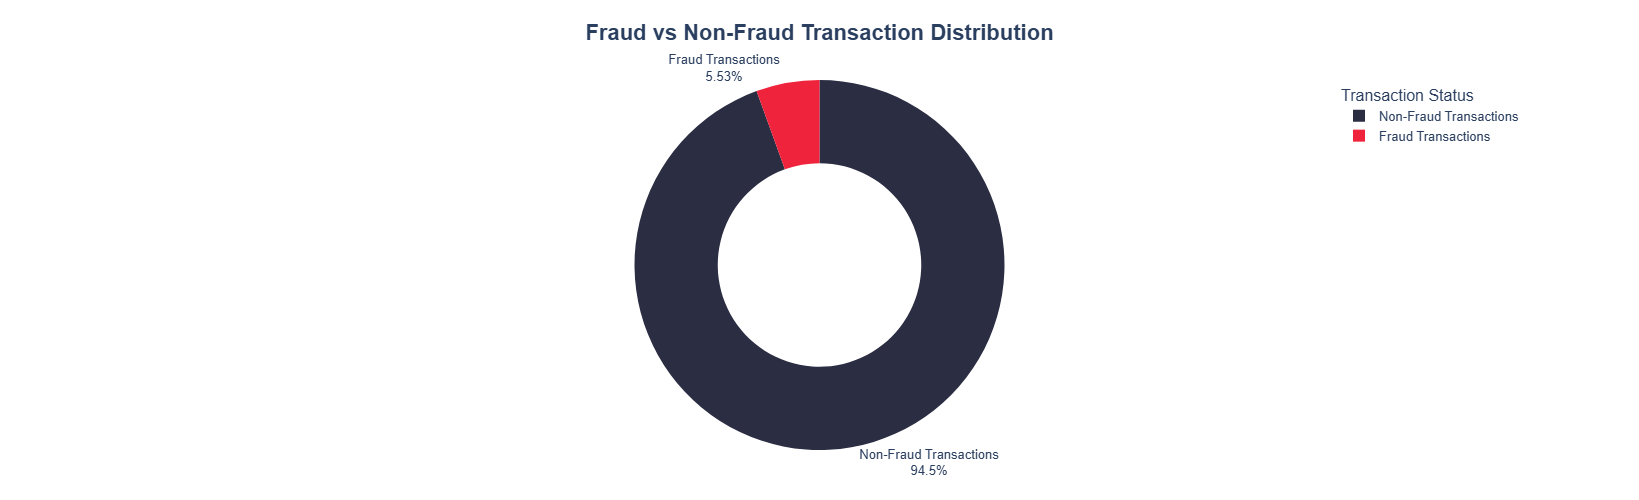

,transaction_status,transaction_count
0,Non-Fraud Transactions,944745
1,Fraud Transactions,55255


In [6]:
total_transaction = df["transaction_id"].count()
print(f"Total Transactions :- {total_transaction}")

total_customers = df["customer_id"].nunique()
print(f"Total Customers :- {total_customers}")


total_customer_affetced_by_fraud = df[df["is_fraud"] == 1]["customer_id"].nunique()
print(f"Total Customers Affected by Fraud :- {total_customer_affetced_by_fraud}")


rate = round(total_customer_affetced_by_fraud * 100 / total_customers, 0)
print(f"Total Customers Affected by Fraud  :- {rate}%")

# ---------------------------------------------------------------------------------- #
# Count fraud and non-fraud transactions
fraud_status_summary = (
    df["is_fraud"]
    .value_counts()
    .rename(index={
        0: "Non-Fraud Transactions",
        1: "Fraud Transactions"
    })
    .reset_index()
)

fraud_status_summary.columns = ["transaction_status", "transaction_count"]


# Create donut chart
fig = px.pie(
    fraud_status_summary,
    values="transaction_count",
    names="transaction_status",
    title="Fraud vs Non-Fraud Transaction Distribution",
    hole=0.55,
    height=500,
    width=800,
    color="transaction_status",
    color_discrete_map={
        "Non-Fraud Transactions": colors["dark_navy"],
        "Fraud Transactions": colors["fraud_red"]
    }
)


# Improve chart appearance
fig.update_traces(
    textposition="outside",
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Transactions: %{value:,}<br>Share: %{percent}<extra></extra>"
)

fig.update_layout(
    title={
        "text": "<b>Fraud vs Non-Fraud Transaction Distribution</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 22}
    },
    font={"family": "Arial", "size": 13},
    legend_title_text="Transaction Status",
    margin=dict(t=80, b=50, l=50, r=50),
    showlegend=True
)

fig.show()

fraud_status_summary

### Key Insight
#### Across the full dataset, 55,255 of 1,000,000 transactions were fraudulent, giving an overall fraud rate of approximately 5.53%. Among 198,662 unique customers, 48,121 were affected by at least one fraudulent transaction.


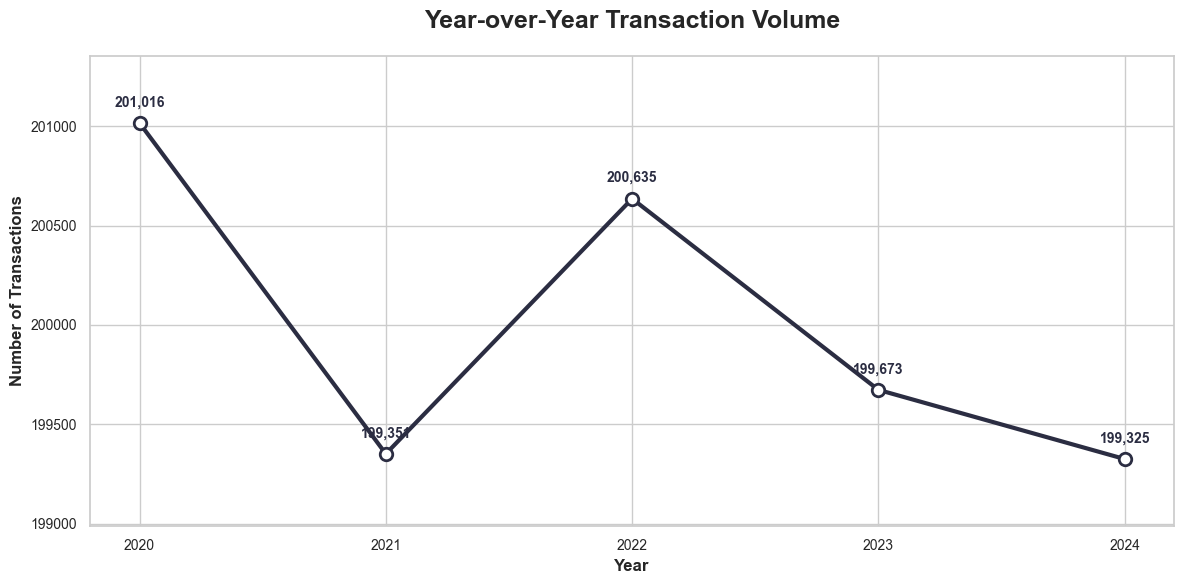

is_fraud,year,non_fraud_transactions,fraud_transactions,total_transactions,non_fraud_rate,fraud_rate
0,2020,189975,11041,201016,94.51,5.49
1,2021,188292,11059,199351,94.45,5.55
2,2022,189566,11069,200635,94.48,5.52
3,2023,188536,11137,199673,94.42,5.58
4,2024,188376,10949,199325,94.51,5.49


In [7]:
# Year-over-year transaction summary
yearly_transaction_summary = (
    df.pivot_table(
        index=df["transaction_date"].dt.year,
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        "transaction_date": "year",
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
    .sort_values("year")
)

# Calculate total transactions
yearly_transaction_summary["total_transactions"] = (yearly_transaction_summary["non_fraud_transactions"] + yearly_transaction_summary["fraud_transactions"])

# Calculate transaction rates
yearly_transaction_summary["non_fraud_rate"] = (yearly_transaction_summary["non_fraud_transactions"] / yearly_transaction_summary["total_transactions"] * 100).round(2)

yearly_transaction_summary["fraud_rate"] = (yearly_transaction_summary["fraud_transactions"] / yearly_transaction_summary["total_transactions"] * 100 ).round(2)


# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=yearly_transaction_summary,
    x="year",
    y="total_transactions",
    color="#2B2D42",
    linewidth=3,
    marker="o",
    markersize=9,
    markerfacecolor="white",
    markeredgecolor="#2B2D42",
    markeredgewidth=2,
    ax=ax
)

# Add transaction count labels
for year, transactions in zip(
    yearly_transaction_summary["year"],
    yearly_transaction_summary["total_transactions"]
):
    ax.annotate(
        f"{transactions:,.0f}",
        xy=(year, transactions),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold",
        color= colors["dark_navy"]
    )

# Titles and labels
ax.set_title(
    "Year-over-Year Transaction Volume",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Year", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Transactions", fontsize=12, fontweight="bold")

# Format axes
ax.set_xticks(yearly_transaction_summary["year"])
ax.tick_params(axis="both", labelsize=10)


plt.tight_layout()
plt.margins(y = 0.2)
plt.show()

yearly_transaction_summary

### Key Insight
#### Annual transaction volume remained close to 200,000 transactions from 2020 through 2024. Fraud rates were also highly stable, ranging from approximately 5.49% to 5.58%. This indicates a persistent fraud problem rather than a strong upward or downward long-term trend.


In [8]:
latest_year = df["transaction_date"].dt.year.max()

latest_year_data = df[df["transaction_date"].dt.year == latest_year]

Total Customers 2024 :- 126236
Total Customers Affected by Fraud 2024 :- 10643
Total Customers Affected by Fraud 2024 :- 8.0%


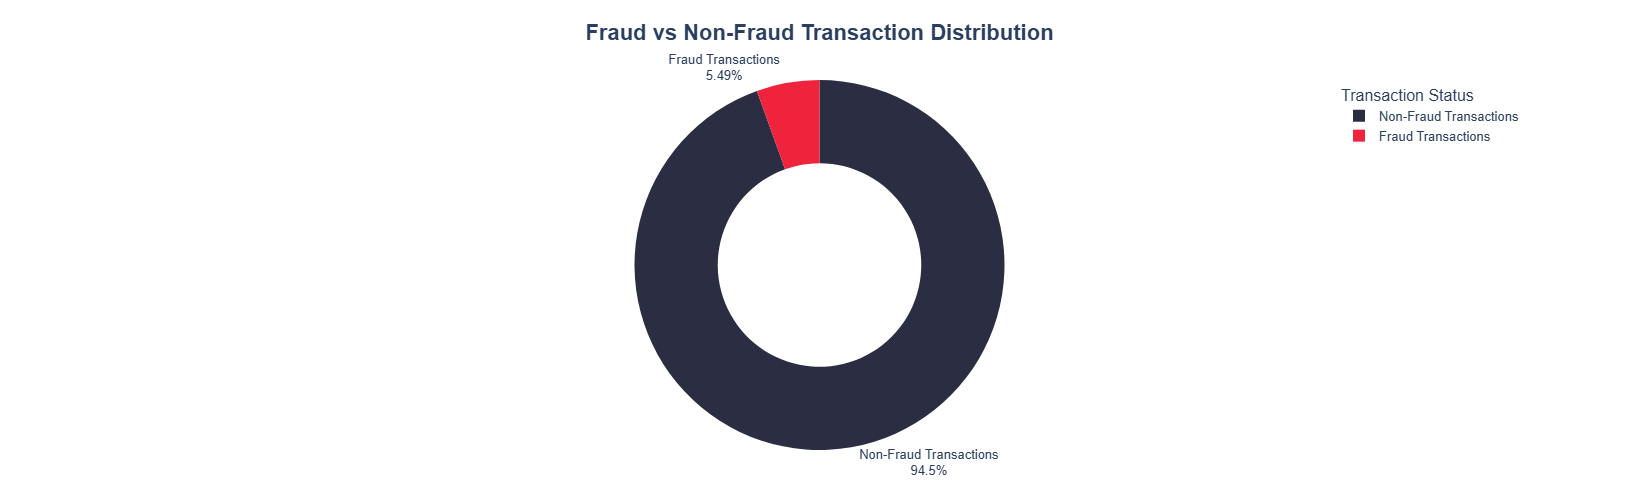

,transaction_status,transaction_count
0,Non-Fraud Transactions,188376
1,Fraud Transactions,10949


In [9]:
total_customers = latest_year_data["customer_id"].nunique()
print(f"Total Customers {latest_year} :- {total_customers}")

total_customer_affetced_by_fraud = latest_year_data[latest_year_data["is_fraud"] == 1]["customer_id"].nunique()
print(f"Total Customers Affected by Fraud {latest_year} :- {total_customer_affetced_by_fraud}")

rate = round(total_customer_affetced_by_fraud * 100 / total_customers, 0)
print(f"Total Customers Affected by Fraud {latest_year} :- {rate}%")

# ----------------------------------------------------------------------------#

# Count fraud and non-fraud transactions
fraud_status_summary = (
    latest_year_data["is_fraud"]
    .value_counts()
    .rename(index={
        0: "Non-Fraud Transactions",
        1: "Fraud Transactions"
    })
    .reset_index()
)

fraud_status_summary.columns = ["transaction_status", "transaction_count"]


# Create donut chart
fig = px.pie(
    fraud_status_summary,
    values="transaction_count",
    names="transaction_status",
    title="Fraud vs Non-Fraud Transaction Distribution",
    hole=0.55,
    height=500,
    width=800,
    color="transaction_status",
    color_discrete_map={
        "Non-Fraud Transactions": colors["dark_navy"],
        "Fraud Transactions": colors["fraud_red"]
    }
)


# Improve chart appearance
fig.update_traces(
    textposition="outside",
    textinfo="percent+label",
    hovertemplate="<b>%{label}</b><br>Transactions: %{value:,}<br>Share: %{percent}<extra></extra>"
)

fig.update_layout(
    title={
        "text": "<b>Fraud vs Non-Fraud Transaction Distribution</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 22}
    },
    font={"family": "Arial", "size": 13},
    legend_title_text="Transaction Status",
    margin=dict(t=80, b=50, l=50, r=50),
    showlegend=True
)

fig.show()

fraud_status_summary

### Key Insight
#### In 2024, the dataset contains 199,325 transactions, of which 10,949 were fraudulent, producing a fraud rate of approximately 5.49%. There were 126,236 unique customers in 2024, and 10,643 of them were affected by fraud.


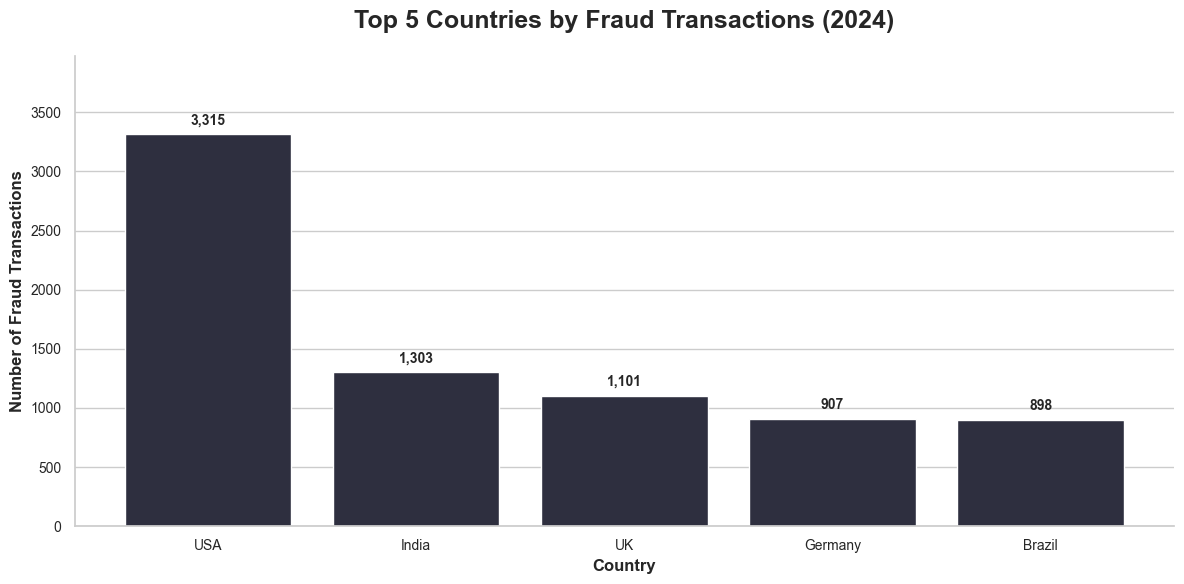

is_fraud,country,non_fraud_transactions,fraud_transactions,total_transactions,non_fraud_rate,fraud_rate
0,USA,56437,3315,59752,94.45,5.55
1,India,22662,1303,23965,94.56,5.44
2,UK,19067,1101,20168,94.54,5.46
3,Germany,14970,907,15877,94.29,5.71
4,Brazil,14954,898,15852,94.34,5.66
5,France,13319,761,14080,94.60,5.40
6,Canada,13063,747,13810,94.59,5.41
7,Japan,13069,706,13775,94.87,5.13
8,Mexico,11482,648,12130,94.66,5.34
9,Australia,9353,563,9916,94.32,5.68


In [10]:
# Country-level fraud summary for the latest year
country_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="country",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)

country_fraud_summary["total_transactions"] = (country_fraud_summary["non_fraud_transactions"] + country_fraud_summary["fraud_transactions"])

country_fraud_summary["non_fraud_rate"] = (country_fraud_summary["non_fraud_transactions"] / country_fraud_summary["total_transactions"] * 100).round(2)
country_fraud_summary["fraud_rate"] = (country_fraud_summary["fraud_transactions"]/ country_fraud_summary["total_transactions"]* 100).round(2)


# Sort countries by number of fraud transactions
country_fraud_summary = (
    country_fraud_summary
    .sort_values("fraud_transactions", ascending=False)
    .reset_index()
)

# Select top 5 countries by fraud transaction count
top_5_fraud_countries = country_fraud_summary.head(5)


# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=top_5_fraud_countries,
    x="country",
    y="fraud_transactions",
    color=colors["dark_navy"],
    ax=ax
)

# Add value labels
for container in ax.containers:
    ax.bar_label(
        container,
         fmt="{:,.0f}",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

# Titles and labels
ax.set_title(
    f"Top 5 Countries by Fraud Transactions ({latest_year})",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel("Country", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Fraud Transactions", fontsize=12, fontweight="bold")

ax.tick_params(axis="both", labelsize=10)

# Add space above bars for labels
ax.margins(y=0.2, x=0.05)

sns.despine()
plt.tight_layout()
plt.show()

country_fraud_summary

### Key Insight
#### The USA recorded the highest fraud volume in 2024 with 3,315 fraudulent transactions, followed by India with 1,303 and the UK with 1,101. However, the fraud rates of the listed countries were relatively close, generally around 5.1% to 5.7%.


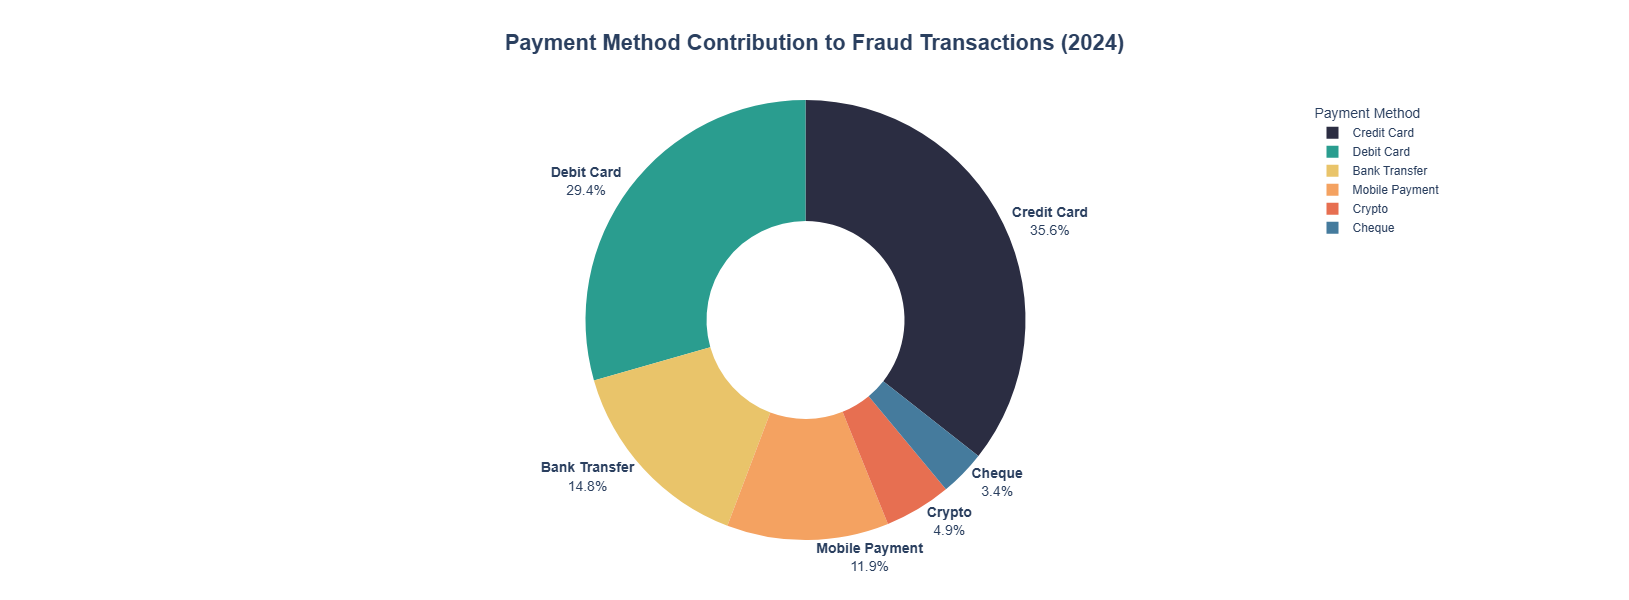

is_fraud,payment_method,non_fraud_transactions,fraud_transactions,total_transactions,non_fraud_rate,fraud_rate
0,Credit Card,66076,3899,69975,94.43,5.57
1,Debit Card,56507,3222,59729,94.61,5.39
2,Bank Transfer,28102,1620,29722,94.55,5.45
3,Mobile Payment,22697,1302,23999,94.57,5.43
4,Crypto,9431,537,9968,94.61,5.39
5,Cheque,5563,369,5932,93.78,6.22


In [25]:
# Payment method transaction summary for the latest year
payment_method_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="payment_method",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)

# Calculate total transactions
payment_method_fraud_summary["total_transactions"] = (
    payment_method_fraud_summary["non_fraud_transactions"]
    + payment_method_fraud_summary["fraud_transactions"]
)

# Calculate fraud and non-fraud rates
payment_method_fraud_summary["non_fraud_rate"] = (
    payment_method_fraud_summary["non_fraud_transactions"]
    / payment_method_fraud_summary["total_transactions"]
    * 100
).round(2)

payment_method_fraud_summary["fraud_rate"] = (
    payment_method_fraud_summary["fraud_transactions"]
    / payment_method_fraud_summary["total_transactions"]
    * 100
).round(2)

# Sort by fraud transactions for this visualization
payment_method_fraud_summary = (
    payment_method_fraud_summary
    .sort_values("fraud_transactions", ascending=False)
    .reset_index()
)


# Color palette



# Create donut chart
fig = px.pie(
    payment_method_fraud_summary,
    values="fraud_transactions",
    names="payment_method",
    hole=0.45,
    custom_data=["fraud_rate"],
    height=600,
    width=850,
    color_discrete_sequence=[colors[i] for i in colors if i not in ["fraud_red", "muted_red", "dark_teal"]]
)


# Customize chart
fig.update_traces(
    textposition="outside",
    textinfo="label+percent",
    textfont_size=14,
    texttemplate="<b>%{label}</b><br>%{percent:.1%}",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Fraud Transactions: %{value:,}<br>"
        "Share of Total Fraud: %{percent:.2%}<br>"
        "Fraud Rate :- %{customdata[0]:.2f}"
        "<extra></extra>"
    )
)


fig.update_layout(
    title={
        "text": f"<b>Payment Method Contribution to Fraud Transactions ({latest_year})</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 22}
    },

    legend={
        "title": {
            "text": "Payment Method",
            "font": {"size": 14}
        },
        "font": {"size": 12}
    },

    font={
        "family": "Arial",
        "size": 13
    },

    margin=dict(
        t=100,
        b=60,
        l=100,
        r=100
    )
)

fig.show()

payment_method_fraud_summary

### Key Insight
#### Credit cards contributed the largest fraud volume in 2024 with 3,899 fraudulent transactions, followed by debit cards with 3,222. However, cheque transactions had the highest observed fraud rate at 6.22%, while the other payment methods were mostly around 5.4% to 5.6%.


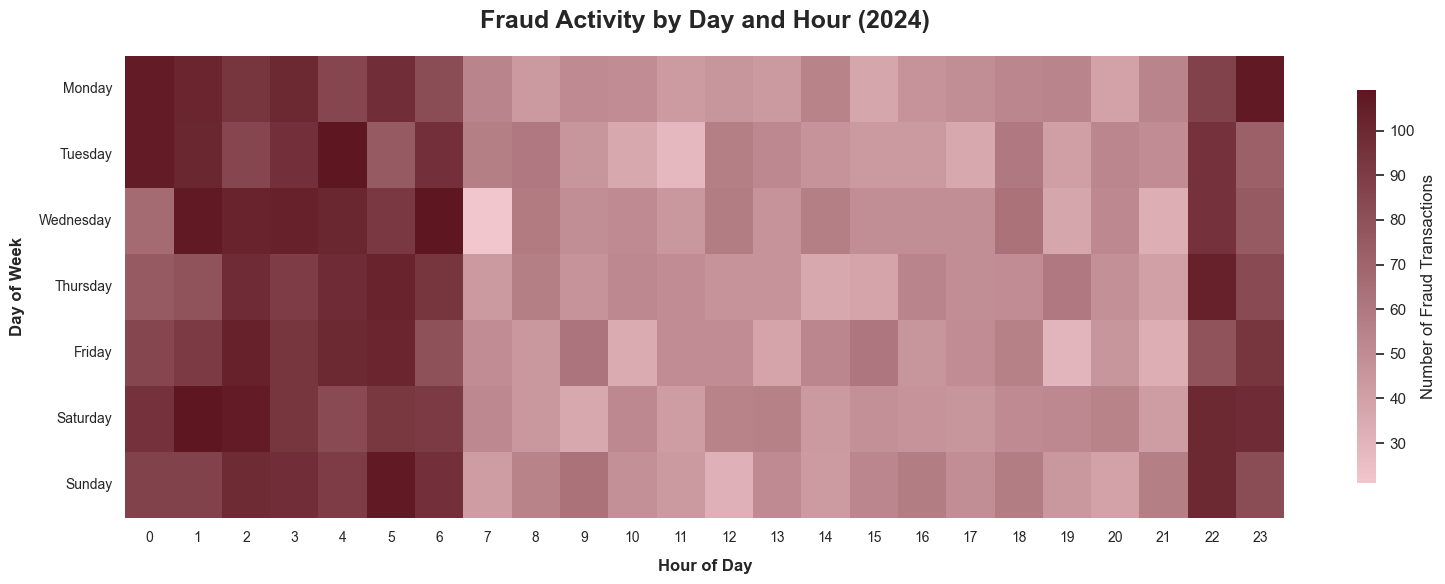

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
transaction_date,,,,,,,,,,,,,,,,,,,,,
Monday,106,102,94,100,85,97,82,54,44,51,...,55,37,47,49,53,54,39,54,87,107
Tuesday,106,101,85,96,109,75,96,57,60,46,...,47,44,44,36,60,41,53,50,95,72
Wednesday,67,107,103,104,101,92,109,21,59,49,...,57,49,49,49,63,37,52,33,95,75
Thursday,75,79,98,90,98,103,94,44,57,47,...,36,38,54,49,50,60,48,40,104,83
Friday,85,91,104,94,100,102,80,50,45,62,...,53,61,46,50,56,30,46,33,79,94
Saturday,95,109,106,94,83,93,91,52,45,36,...,44,48,47,46,51,52,55,42,100,98
Sunday,87,87,99,97,90,107,96,42,55,63,...,43,53,58,49,58,45,39,57,100,82


In [12]:
# Filter fraud transactions for the latest year
latest_year_fraud = latest_year_data[latest_year_data["is_fraud"] == 1].copy()


# Create day-of-week × hour fraud transaction matrix
fraud_hour_day_matrix = latest_year_fraud.pivot_table(
    index=latest_year_fraud["transaction_date"].dt.weekday,
    columns="hour_of_day",
    values="transaction_id",
    aggfunc="count",
    fill_value=0
)


# Rename weekday numbers
fraud_hour_day_matrix = fraud_hour_day_matrix.rename(
    index={
        0: "Monday",
        1: "Tuesday",
        2: "Wednesday",
        3: "Thursday",
        4: "Friday",
        5: "Saturday",
        6: "Sunday"
    }
)


# Plot heatmap
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    fraud_hour_day_matrix,
    cmap= my_cmap,
    cbar_kws={
        "label": "Number of Fraud Transactions",
        "shrink": 0.85
    },
    ax=ax
)


# Titles and labels
ax.set_title(
    f"Fraud Activity by Day and Hour ({latest_year})",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Hour of Day",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Day of Week",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.tick_params(
    axis="both",
    labelsize=10
)

plt.tight_layout()
plt.show()

fraud_hour_day_matrix

#

#### Key Insight
#### The 2024 hour-by-weekday heatmap shows that fraud activity is not evenly distributed throughout the day. Late-night and early-morning periods, particularly around 22:00 through 06:00, frequently show higher fraud counts than many daytime hours.


In [23]:
ans = latest_year_fraud["fraud_type"].value_counts().reset_index().rename(columns = {"count" : "total_transaction"})

# top 3 frauds that happens highest
ans.sort_values(by = "total_transaction", ascending = False)

,fraud_type,total_transaction
0,Phishing,1852
1,Identity Theft,1841
2,Account Takeover,1830
3,Friendly Fraud,1824
4,Synthetic Identity,1822
5,Card Cloning,1780


### Key Insight
#### The three most frequent fraud types in 2024 were Phishing (1,852 transactions), Identity Theft (1,841), and Account Takeover (1,830). The counts are close, indicating that fraud is distributed across multiple major attack types rather than being dominated by a single category.

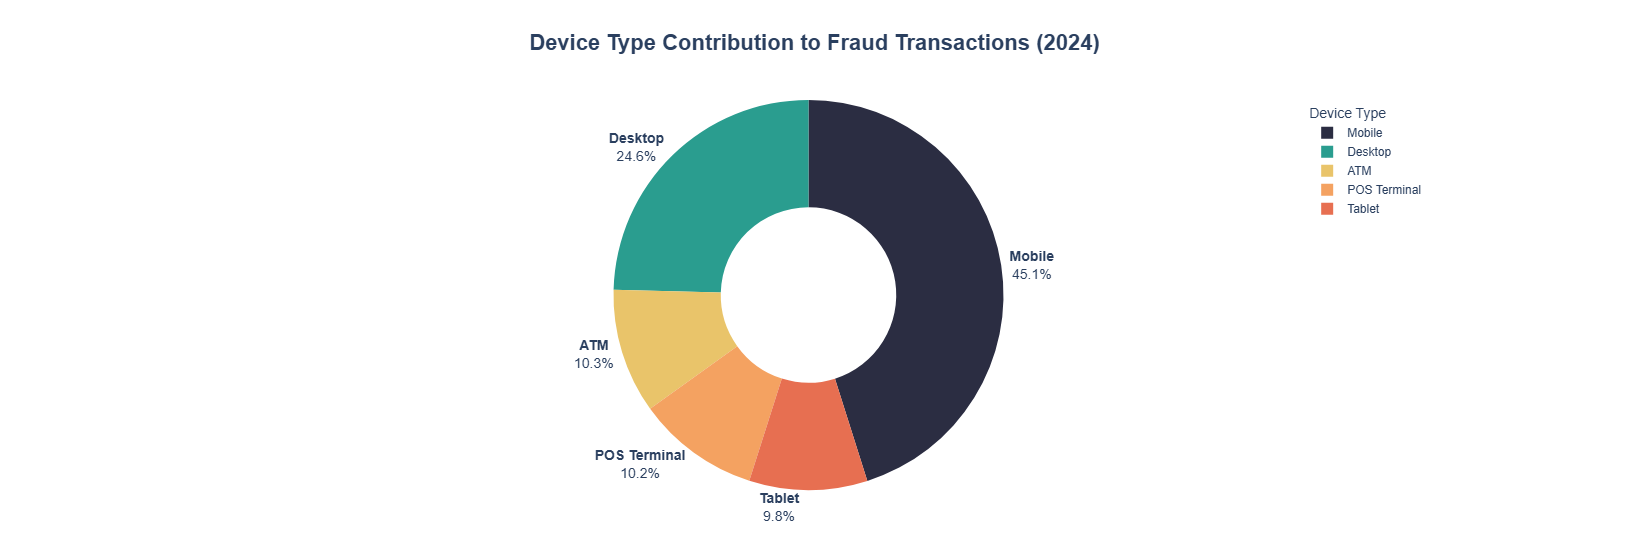

is_fraud,device_type,non_fraud_transactions,fraud_transactions,total_transactions,non_fraud_rate,fraud_rate
0,Mobile,84613,4940,89553,94.48,5.52
1,Desktop,47012,2690,49702,94.59,5.41
2,ATM,19040,1133,20173,94.38,5.62
3,POS Terminal,18709,1114,19823,94.38,5.62
4,Tablet,19002,1072,20074,94.66,5.34


In [26]:
# Device-level transaction summary for the latest year
device_type_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="device_type",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)


# Calculate total transactions
device_type_fraud_summary["total_transactions"] = (
    device_type_fraud_summary["non_fraud_transactions"]
    + device_type_fraud_summary["fraud_transactions"]
)


# Calculate fraud and non-fraud rates
device_type_fraud_summary["non_fraud_rate"] = (
    device_type_fraud_summary["non_fraud_transactions"]
    / device_type_fraud_summary["total_transactions"]
    * 100
).round(2)

device_type_fraud_summary["fraud_rate"] = (
    device_type_fraud_summary["fraud_transactions"]
    / device_type_fraud_summary["total_transactions"]
    * 100
).round(2)


# Sort by fraud transaction count
device_type_fraud_summary = (
    device_type_fraud_summary
    .sort_values("fraud_transactions", ascending=False)
    .reset_index(drop=True)
)


# Create donut chart
fig = px.pie(
    device_type_fraud_summary,
    values="fraud_transactions",
    names="device_type",
    custom_data=["total_transactions"],
    hole=0.45,
    height=550,
    width=850,
    color_discrete_sequence=[colors[i] for i in colors if i not in ["fraud_red", "muted_red", "dark_teal"]]
)


# Customize chart
fig.update_traces(
    textposition="outside",
    textinfo="label+percent",
    texttemplate="<b>%{label}</b><br>%{percent:.1%}",
    textfont_size=14,

    hovertemplate=(
        "<b>%{label}</b><br>"
        "Fraud Transactions: %{value:,}<br>"
        "Total Transactions: %{customdata[0]:,.0f}<br>"
        "Contribution to Total Fraud: %{percent:.2%}<br>"
        "<extra></extra>"
    )
)


# Customize layout
fig.update_layout(
    title={
        "text": f"<b>Device Type Contribution to Fraud Transactions ({latest_year})</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": {
            "size": 22
        }
    },

    legend={
        "title": {
            "text": "Device Type",
            "font": {"size": 14}
        },
        "font": {
            "size": 12
        }
    },

    font={
        "family": "Arial",
        "size": 13
    },

    margin=dict(
        t=100,
        b=60,
        l=100,
        r=100
    )
)


fig.show()

device_type_fraud_summary

### Key Insight
#### Mobile devices generated the largest number of fraudulent transactions in 2024 with 4,940 cases, followed by Desktop with 2,690. However, device-level fraud rates were relatively similar, ranging from approximately 5.34% to 5.62%.


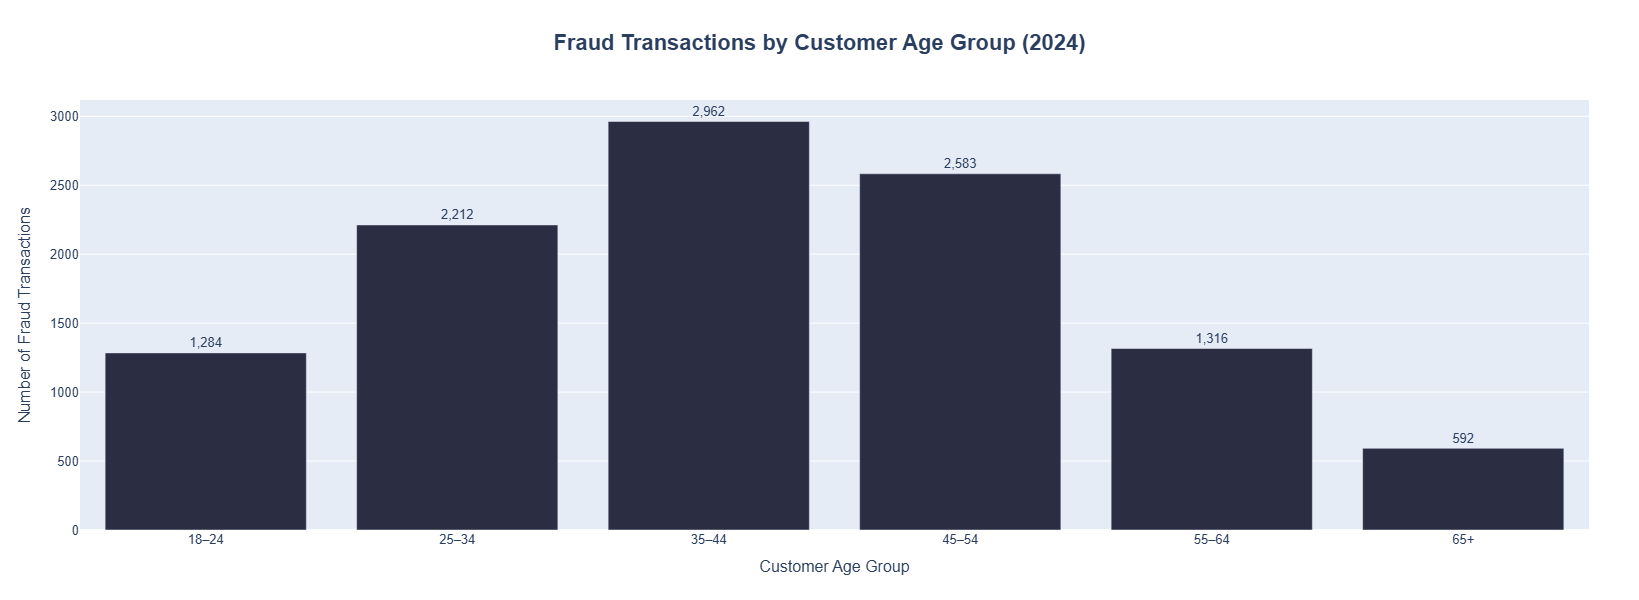

,age_group,fraud_transactions
0,18–24,1284
1,25–34,2212
2,35–44,2962
3,45–54,2583
4,55–64,1316
5,65+,592


In [15]:
# Get the latest year available in the dataset
latest_year = df["transaction_date"].dt.year.max()

# Filter fraud transactions for the latest year
latest_year_fraud_transactions = latest_year_data[
    latest_year_data["is_fraud"] == 1
].copy()


# Define age groups
age_bins = [17, 24, 34, 44, 54, 64, float("inf")]

age_labels = [
    "18–24",
    "25–34",
    "35–44",
    "45–54",
    "55–64",
    "65+"
]


# Create age groups
latest_year_fraud_transactions["age_group"] = pd.cut(
    latest_year_fraud_transactions["customer_age"],
    bins=age_bins,
    labels=age_labels
)


# Count fraud transactions by age group
age_group_fraud_summary = (
    latest_year_fraud_transactions
    .groupby("age_group", observed=False)
    .agg(
        fraud_transactions=("transaction_id", "count")
    )
    .reset_index()
)


# Create bar chart
fig = px.bar(
    age_group_fraud_summary,
    x="age_group",
    y="fraud_transactions",
    text="fraud_transactions",
    width=1000,
    height=600,
    color_discrete_sequence=["#2B2D42"],
    labels={
        "age_group": "Customer Age Group",
        "fraud_transactions": "Fraud Transactions"
    }
)


# Customize bars
fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside",
    hovertemplate=(
        "<b>Age Group: %{x}</b><br>"
        "Fraud Transactions: %{y:,}"
        "<extra></extra>"
    )
)


# Customize layout
fig.update_layout(
    title={
        "text": f"<b>Fraud Transactions by Customer Age Group ({latest_year})</b>",
        "x": 0.5,
        "xanchor": "center",
        "font": {"size": 22}
    },

    xaxis_title="Customer Age Group",
    yaxis_title="Number of Fraud Transactions",

    font={
        "family": "Arial",
        "size": 13
    },

    showlegend=False,

    margin=dict(
        l=80,
        r=50,
        t=100,
        b=70
    )
)


fig.show()

age_group_fraud_summary

### Key Insight
#### Among fraudulent transactions in 2024, the 35–44 age group recorded the largest fraud count (2,962), followed by 45–54 (2,583) and 25–34 (2,212).


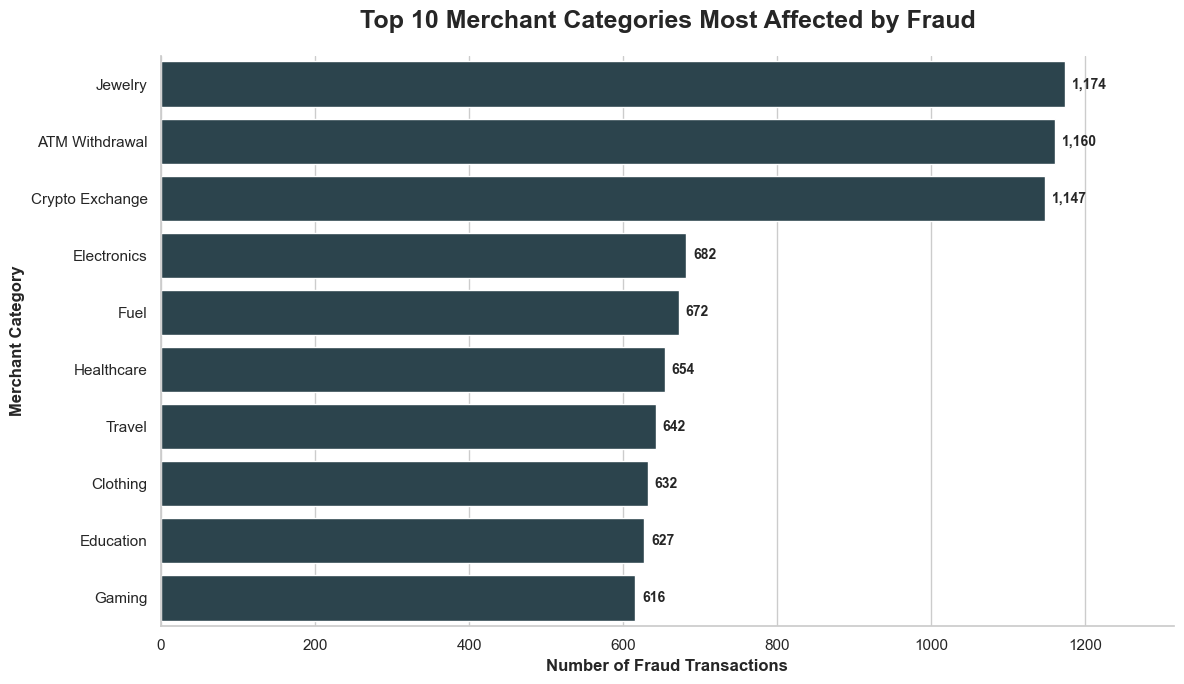

is_fraud,merchant_category,non_fraud_transactions,fraud_transactions,total_transactions,fraud_rate
10,Jewelry,12084,1174,13258,8.86
0,ATM Withdrawal,12038,1160,13198,8.79
2,Crypto Exchange,12028,1147,13175,8.71
4,Electronics,12847,682,13529,5.04
6,Fuel,12874,672,13546,4.96
9,Healthcare,12570,654,13224,4.95
13,Travel,12549,642,13191,4.87
1,Clothing,12686,632,13318,4.75
3,Education,12705,627,13332,4.70
7,Gaming,12425,616,13041,4.72


In [16]:
# Create merchant category fraud summary
merchant_category_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="merchant_category",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)


# Calculate total transactions
merchant_category_fraud_summary["total_transactions"] = (
    merchant_category_fraud_summary["non_fraud_transactions"]
    + merchant_category_fraud_summary["fraud_transactions"]
)


# Calculate fraud rate
merchant_category_fraud_summary["fraud_rate"] = (
    merchant_category_fraud_summary["fraud_transactions"]
    / merchant_category_fraud_summary["total_transactions"]
    * 100
).round(2)


# Get top 10 merchant categories by fraud transactions
top_fraud_merchant_categories = (
    merchant_category_fraud_summary
    .sort_values("fraud_transactions", ascending=False)
    .head(10)
    .sort_values("fraud_transactions", ascending=False)
)

# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_fraud_merchant_categories,
    x="fraud_transactions",
    y="merchant_category",
    color=colors["dark_teal"],
    ax=ax
)


# Add fraud transaction labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:,.0f}"
            for value in container.datavalues
        ],
        padding=5,
        fontsize=10,
        fontweight="bold"
    )


# Customize title and axis labels
ax.set_title(
    "Top 10 Merchant Categories Most Affected by Fraud",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Number of Fraud Transactions",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Merchant Category",
    fontsize=12,
    fontweight="bold"
)


# Add space for data labels
ax.margins(x=0.12)

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.show()

top_fraud_merchant_categories

### Key Insight
#### Jewelry had the highest observed merchant-category fraud rate in 2024 at 8.86%, followed by ATM Withdrawal at 8.79% and Crypto Exchange at 8.71%. These rates were substantially higher than categories such as Electronics (5.04%), Fuel (4.96%), and Healthcare (4.95%


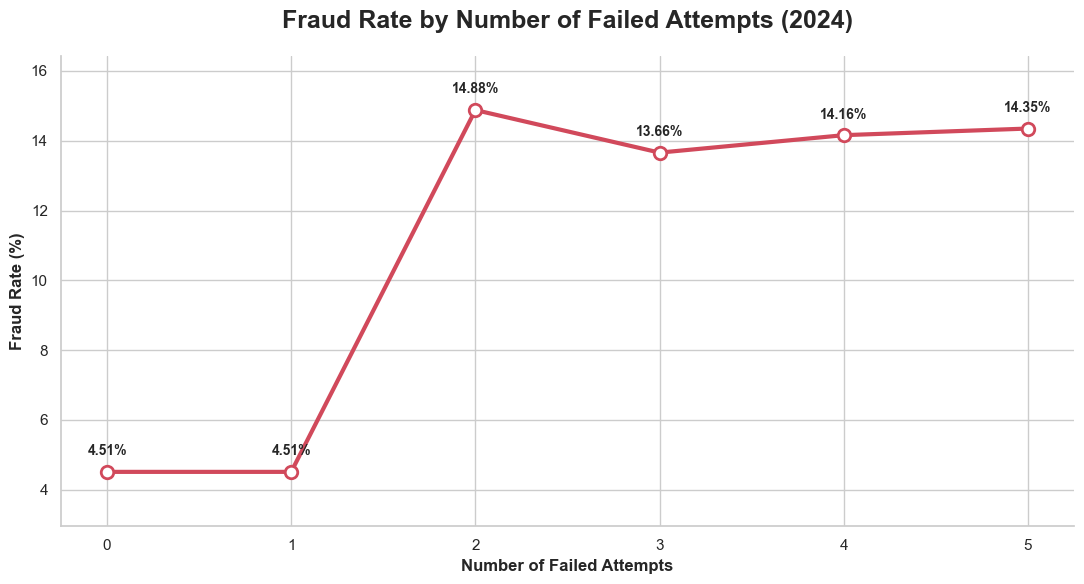

is_fraud,failed_attempts,non_fraud_transactions,fraud_transactions,total_transactions,fraud_rate
0,0,152287,7192,159479,4.51
1,1,19108,902,20010,4.51
2,2,8423,1473,9896,14.88
3,3,5105,808,5913,13.66
4,4,1740,287,2027,14.16
5,5,1713,287,2000,14.35


In [17]:
# Failed attempts transaction summary for the latest year
failed_attempts_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="failed_attempts",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)


# Calculate total transactions
failed_attempts_fraud_summary["total_transactions"] = (
    failed_attempts_fraud_summary["non_fraud_transactions"]
    + failed_attempts_fraud_summary["fraud_transactions"]
)


# Calculate fraud rate
failed_attempts_fraud_summary["fraud_rate"] = (
    failed_attempts_fraud_summary["fraud_transactions"]
    / failed_attempts_fraud_summary["total_transactions"]
    * 100
).round(2)


# Sort by number of failed attempts
failed_attempts_fraud_summary = (
    failed_attempts_fraud_summary
    .sort_values("failed_attempts")
    .reset_index(drop=True)
)


# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(11, 6))

sns.lineplot(
    data=failed_attempts_fraud_summary,
    x="failed_attempts",
    y="fraud_rate",
    marker="o",
    markersize=9,
    linewidth=3,
    color="#D1495B",
    markerfacecolor="white",
    markeredgecolor="#D1495B",
    markeredgewidth=2,
    ax=ax
)


# Add fraud rate labels
for failed_attempts, fraud_rate in zip(
    failed_attempts_fraud_summary["failed_attempts"],
    failed_attempts_fraud_summary["fraud_rate"]
):
    ax.annotate(
        f"{fraud_rate:.2f}%",
        xy=(failed_attempts, fraud_rate),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )


# Titles and labels
ax.set_title(
    f"Fraud Rate by Number of Failed Attempts ({latest_year})",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Number of Failed Attempts",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Fraud Rate (%)",
    fontsize=12,
    fontweight="bold"
)

# Show every failed-attempt value
ax.set_xticks(failed_attempts_fraud_summary["failed_attempts"])

# Add space for data labels
ax.margins(y=0.15)

sns.despine()
plt.tight_layout()
plt.show()

failed_attempts_fraud_summary

### Key Insight
#### Fraud rates were 4.51% for transactions associated with zero or one failed attempt, but increased sharply to 14.88% at two failed attempts and remained around 13.66% to 14.35% for three to five failed attempts.

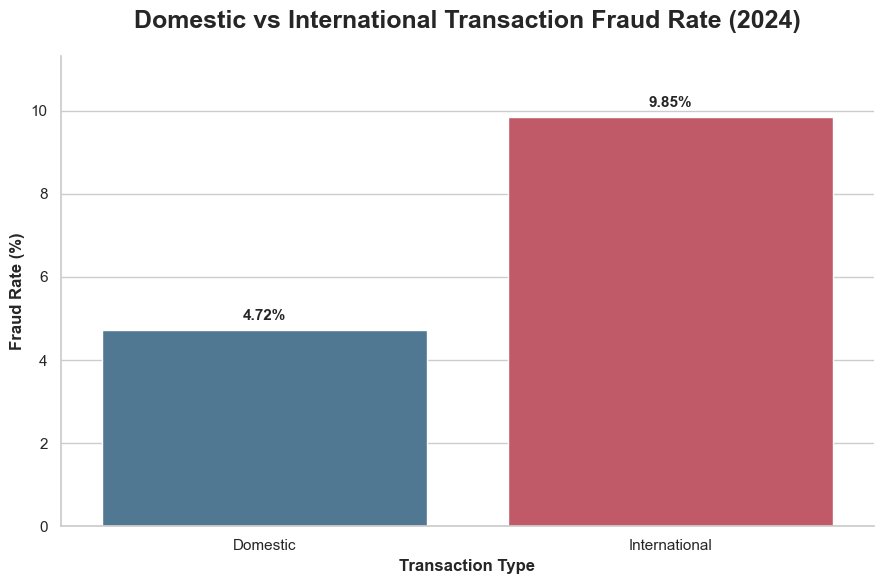

is_fraud,is_international,non_fraud_transactions,fraud_transactions,transaction_type,total_transactions,fraud_rate
0,0,161209,7981,Domestic,169190,4.72
1,1,27167,2968,International,30135,9.85


In [18]:
# International vs Domestic Fraud Rate

# International vs domestic transaction summary for the latest year
international_fraud_summary = (
    latest_year_data
    .pivot_table(
        index="is_international",
        columns="is_fraud",
        values="transaction_id",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
    .rename(columns={
        0: "non_fraud_transactions",
        1: "fraud_transactions"
    })
)


# Create readable transaction type labels
international_fraud_summary["transaction_type"] = np.where(
    international_fraud_summary["is_international"] == 0,
    "Domestic",
    "International"
)


# Calculate total transactions
international_fraud_summary["total_transactions"] = (
    international_fraud_summary["non_fraud_transactions"]
    + international_fraud_summary["fraud_transactions"]
)


# Calculate fraud rate
international_fraud_summary["fraud_rate"] = (
    international_fraud_summary["fraud_transactions"]
    / international_fraud_summary["total_transactions"]
    * 100
).round(2)


# Plot
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=international_fraud_summary,
    x="transaction_type",
    y="fraud_rate",
    hue="transaction_type",
    palette={
        "Domestic": colors["steel_blue"],
        "International": colors["muted_red"]
    },
    legend=False,
    ax=ax
)


# Add fraud rate labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value:.2f}%"
            for value in container.datavalues
        ],
        padding=5,
        fontsize=11,
        fontweight="bold"
    )


# Titles and labels
ax.set_title(
    f"Domestic vs International Transaction Fraud Rate ({latest_year})",
    fontsize=18,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Transaction Type",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Fraud Rate (%)",
    fontsize=12,
    fontweight="bold"
)

# Add space above bars
ax.margins(y=0.15)

sns.despine()
plt.tight_layout()
plt.show()

international_fraud_summary

### Key Insight
#### International transactions had a fraud rate of 9.85% in 2024, compared with 4.72% for domestic transactions. The international fraud rate was therefore more than twice the domestic rate in this dataset.


### Priority Findings for the Presentation
#### •	Fraud is persistent: annual fraud rates remained near 5.5% from 2020 to 2024.
#### •	Merchant category is a meaningful risk differentiator: Jewelry, ATM Withdrawal, and Crypto Exchange exceeded 8.7% fraud rates.
#### •	Failed attempts are one of the strongest observed risk signals: fraud rate increased from 4.51% to approximately 14% once failed attempts reached two or more.
#### •	International transactions showed materially higher risk: 9.85% fraud rate versus 4.72% for domestic transactions.
#### •	Volume and risk are not the same: Credit Card and Mobile generated the most fraud cases, but they did not have the highest fraud rates within their categories.
